In [1]:
import operator
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Optional, Annotated
from pydantic import BaseModel, Field # BaseModel is a class that we inheret to create models. While Field adds metadata.
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    temperature= 0
)

In [4]:
# This class ensure whenever you evaluate a para/essay you got a 'feedback' and 'score'.
class EvaluationSchema(BaseModel):
    feedback : str = Field(description= 'Detailed Feedback of Paragraph.')
    score : int = Field(description= 'Total Score Out of 10')

In [5]:
struct_model = model.with_structured_output(EvaluationSchema)

In [6]:
essay = '''Starting your day with physical activity can transform your overall well-being and productivity. Morning exercise awakens your body and mind, preparing you for the challenges ahead. When you engage in activities like jogging, yoga, or cycling at dawn, you boost your metabolism and increase energy levels throughout the day. Research shows that people who exercise in the morning tend to be more consistent with their fitness routines. The fresh air and quiet environment create a peaceful atmosphere for reflection and mental clarity. Additionally, morning workouts release endorphins, improving your mood and reducing stress before daily responsibilities begin. This positive start creates a ripple effect, influencing your food choices and decision-making. Whether it's a brisk walk or an intense workout session, dedicating just thirty minutes each morning to physical activity can significantly enhance your physical health, mental focus, and emotional balance, setting a foundation for success.'''
prompt = f'Evaluate the quality of essay and also give it a score out of 10'
struct_model.invoke(prompt)

EvaluationSchema(feedback='The essay is well-structured, with a clear introduction, body, and conclusion. The writer has provided relevant examples to support their arguments, and the language is clear and concise. However, there are some areas that need improvement, such as the use of transitional phrases and more nuanced analysis of the topic.', score=8)

In [7]:
class EssayState(TypedDict, total= False):
    essay : str
    language_feedback : str
    quality_feedback : str
    clarity_feedback : str
    moral_feedback : str
    individual_score : Annotated[list[int], operator.add] # list of int values with metadata.
    avg_score : float

In [8]:
def eval_language(state : EssayState):
    prompt = f'Evaluate the language of the essay and give it a score out of 10 {state['essay']}'
    result = struct_model.invoke(prompt)    
    return {'result' : result.feedback, 'individual_score' : [result.score]}

In [9]:
def eval_quality(state : EssayState):
    prompt = f'Evaluate the quality of the essay and give it a score out of 10 {state['essay']}'
    result = struct_model.invoke(prompt)    
    return {'result' : result.feedback , 'individual_score' : [result.score]}

In [10]:
def eval_clarity(state: EssayState):
    prompt = f'Evaluate the clarity of the essay and give it a score out of 10 {state['essay']}'
    result = struct_model.invoke(prompt)    
    return {'result' : result.feedback , 'individual_score' : [result.score]}

In [11]:
def eval_moral(state : EssayState):
    prompt = f'Evaluate the moral of the essay and give it a score out of 10 {state['essay']}'
    moral = model.invoke(prompt).content
    avg_score = sum(state['individual_score']) / len(state['individual_score'])
    return {'moral' : moral , 'avg_score' : round(avg_score, 3)}

In [12]:
graph = StateGraph(EssayState)

graph.add_node('eval_language', eval_language)
graph.add_node('eval_quality', eval_quality)
graph.add_node('eval_clarity', eval_clarity)
graph.add_node('eval_moral', eval_moral)

graph.add_edge(START, 'eval_language')
graph.add_edge(START, 'eval_quality')
graph.add_edge(START, 'eval_clarity')

graph.add_edge('eval_language', 'eval_moral')
graph.add_edge('eval_quality', 'eval_moral')
graph.add_edge('eval_clarity', 'eval_moral')
graph.add_edge('eval_moral', END)

workflow = graph.compile()

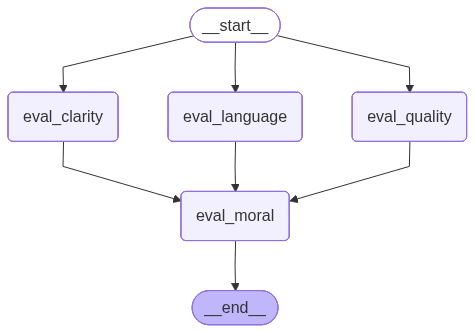

In [13]:
workflow

In [14]:
essay2 = '''Digital tools and platforms have made education more accessible to students worldwide, breaking down geographical and economic barriers. Online courses, educational apps, and virtual classrooms enable learners to access quality content anytime, anywhere. Interactive simulations and multimedia presentations enhance understanding of complex concepts that were once difficult to grasp through traditional methods. '''
user_query = {'essay' : essay2}
final_result = workflow.invoke(user_query)
print(final_result)

{'essay': 'Digital tools and platforms have made education more accessible to students worldwide, breaking down geographical and economic barriers. Online courses, educational apps, and virtual classrooms enable learners to access quality content anytime, anywhere. Interactive simulations and multimedia presentations enhance understanding of complex concepts that were once difficult to grasp through traditional methods. ', 'individual_score': [8, 8, 8], 'avg_score': 8.0}
